# Intelligent Customer Segmentation and Marketing Campaign Optimization System
**Course:** Data Science (BE05016021) â€“ PBL Activity, L.D. College of Engineering
**Author:** Manasvi
**Dataset:** Customer Personality Analysis (Kaggle) â€“ 2,240 customers, 29 attributes

**Objectives**
1. Clean and prepare customer data (feature engineering)
2. Descriptive analytics (EDA) to understand customer behaviour
3. Sampling & Estimation â€“ confidence intervals and hypothesis tests
4. Linear Regression â€“ predict customer total spending
5. Customer Segmentation â€“ K-Means clustering
6. Classification â€“ Logistic Regression, Decision Tree, Random Forest to predict campaign response
7. Interactive Streamlit dashboard for business stakeholders

In [1]:
import os, sys, warnings
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")
sys.path.append(os.getcwd())
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import utils

sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams["figure.dpi"] = 100
os.makedirs("figures", exist_ok=True)
os.makedirs("models", exist_ok=True)

def save(name):
    plt.tight_layout()
    plt.savefig(f"figures/{name}.png", dpi=150, bbox_inches="tight")

## Step 1: Data Understanding and Cleaning
### 1.1 Load the raw data
The Kaggle file is **tab separated**, so we use `sep='\t'`.

In [2]:
raw = utils.load_raw()
print("Shape:", raw.shape)
raw.head()

Shape: (2240, 29)


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


In [3]:
raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   str    
 3   Marital_Status       2240 non-null   str    
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   str    
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   int64  
 16 

### 1.2 Data quality checks
We check for missing values, constant columns, duplicate rows and invalid values.

In [4]:
print("Missing values:\n", raw.isna().sum()[raw.isna().sum() > 0], "\n")
print("Duplicate rows:", raw.drop(columns="ID").duplicated().sum(), "\n")
print("Constant columns:", [c for c in raw.columns if raw[c].nunique() == 1], "\n")
print("Education values:", raw["Education"].value_counts().to_dict(), "\n")
print("Marital_Status values:", raw["Marital_Status"].value_counts().to_dict(), "\n")
print("Oldest birth year:", raw["Year_Birth"].min(), "| Max income:", raw["Income"].max())

Missing values:
 Income    24
dtype: int64 

Duplicate rows: 182 

Constant columns: ['Z_CostContact', 'Z_Revenue'] 

Education values: {'Graduation': 1127, 'PhD': 486, 'Master': 370, '2n Cycle': 203, 'Basic': 54} 

Marital_Status values: {'Married': 864, 'Together': 580, 'Single': 480, 'Divorced': 232, 'Widow': 77, 'Alone': 3, 'Absurd': 2, 'YOLO': 2} 

Oldest birth year: 1893 | Max income: 666666.0


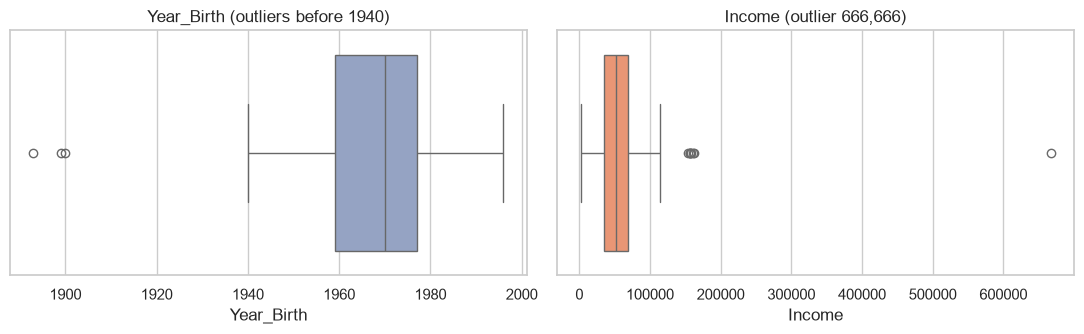

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
sns.boxplot(x=raw["Year_Birth"], ax=ax[0], color="#8da0cb"); ax[0].set_title("Year_Birth (outliers before 1940)")
sns.boxplot(x=raw["Income"], ax=ax[1], color="#fc8d62"); ax[1].set_title("Income (outlier 666,666)")
save("01_outliers_before_cleaning"); plt.show()

**Findings**
- **182 duplicate rows** (identical in all 28 columns except ID – the same customer registered twice) → remove.
- `Income` has **24 missing values** â†’ fill with the **median** (robust to outliers).
- `Z_CostContact` and `Z_Revenue` are **constant** (zero variance) â†’ drop. `ID` is just an identifier â†’ drop.
- `Year_Birth` has impossible values (1893, 1899, 1900 â†’ age 115+) â†’ remove rows with Year_Birth < 1940.
- `Income` has one extreme value (666,666) â†’ remove rows with Income > 600,000.
- `Marital_Status` contains invalid labels ("Absurd", "YOLO", "Alone") â†’ group into **Partner / Single**.
- `Education` has 5 levels â†’ group into **Undergraduate / Graduate / Postgraduate**.

### 1.3 Cleaning + feature engineering
The cleaning logic is written once in `utils.py` (`utils.clean`) so that the notebook and the dashboard use exactly the same preprocessing.

| New feature | Formula |
|---|---|
| Age | 2014 âˆ’ Year_Birth (data collected in 2014) |
| Total_Spent | sum of the 6 Mnt* columns |
| Children | Kidhome + Teenhome |
| Partner | 1 if Married/Together |
| Family_Size | 1 + Partner + Children |
| Is_Parent | 1 if Children > 0 |
| Total_Purchases | Deals + Web + Catalog + Store purchases |
| Total_Accepted_Cmp | AcceptedCmp1 + â€¦ + AcceptedCmp5 |
| Customer_Days | days since enrolment (up to latest enrolment date) |
| Edu_Code | 0 = Undergraduate, 1 = Graduate, 2 = Postgraduate |

In [6]:
df = utils.clean(raw)
print("Rows before:", len(raw), "| Rows after:", len(df), "| Removed:", len(raw) - len(df))
print("Missing values after cleaning:", df.isna().sum().sum())
print("\nEducation:", df["Education"].value_counts().to_dict())
print("Marital_Status:", df["Marital_Status"].value_counts().to_dict())
df[["Age", "Income", "Total_Spent", "Children", "Family_Size", "Total_Purchases",
    "Total_Accepted_Cmp", "Customer_Days", "Response"]].describe().round(1)

Rows before: 2240 | Rows after: 2054 | Removed: 186
Missing values after cleaning: 0

Education: {'Graduate': 1029, 'Postgraduate': 790, 'Undergraduate': 235}
Marital_Status: {'Partner': 1314, 'Single': 740}


,Age,Income,Total_Spent,Children,Family_Size,Total_Purchases,Total_Accepted_Cmp,Customer_Days,Response
count,2054.0,2054.0,2054.0,2054.0,2054.0,2054.0,2054.0,2054.0,2054.0
mean,45.1,52036.0,606.4,1.0,2.6,14.9,0.3,352.7,0.2
std,11.7,21465.0,602.4,0.7,0.9,7.7,0.7,202.2,0.4
min,18.0,1730.0,5.0,0.0,1.0,0.0,0.0,0.0,0.0
25%,37.0,35691.2,69.0,0.0,2.0,8.0,0.0,179.0,0.0
50%,44.0,51381.5,397.0,1.0,3.0,15.0,0.0,352.0,0.0
75%,55.0,68146.5,1046.5,1.0,3.0,21.0,0.0,528.0,0.0
max,74.0,162397.0,2525.0,3.0,5.0,44.0,4.0,699.0,1.0


In [7]:
df.to_csv("data/customers_clean.csv", index=False)
print("Saved cleaned dataset -> data/customers_clean.csv", df.shape)

Saved cleaned dataset -> data/customers_clean.csv (2054, 36)
